<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/lecture_notes/notebooks/01_Time_data_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 2 실습 A: Time Index, Missing Values, and Rolling Statistics
**Notebook:** `01_Time_data_preprocessing.ipynb`

## 실습 목표 (Learning Objectives)
이 실습에서는 다음을 수행합니다.

1. 시계열 데이터의 시간 인덱스와 빈도(frequency)를 확인합니다.
2. 일별 금융 데이터를 사업일 기준 인덱스로 재정렬하는 방법을 익힙니다.
3. 결측치(Missing Values)를 만들고, `dropna()`와 `interpolate()`의 차이를 비교합니다.
4. 로그 수익률(Log Return)을 계산하고 이상치(Outlier) 후보를 탐색합니다.
5. 이동평균(Rolling Mean)과 롤링 표준편차(Rolling Std)를 계산하여 데이터의 흐름과 변동성을 관찰합니다.
6. 일별 데이터를 주별·월별로 재표집(Resampling)하는 방법을 익힙니다.

---

## 왜 이 실습이 중요한가?
시계열 분석에서 전처리는 단순한 '정리 작업'이 아닙니다.  
시간 인덱스를 올바르게 해석하고, 결측치와 이상치의 성격을 구분하며, 적절한 빈도로 데이터를 변환하는 과정은 이후의 정상성 검정, 분해, ARIMA 모델링, 머신러닝 예측의 품질을 좌우합니다.


In [ ]:
# ============================================
# 1. 필수 라이브러리 불러오기
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

from IPython.display import display


## 1. 온라인 환경 준비
이번 실습은 Google Colab 또는 Jupyter Notebook에서 바로 실행할 수 있도록 구성했습니다.

금융 데이터를 쉽게 불러오기 위해 `yfinance`를 사용합니다.  
설치되어 있지 않다면 자동으로 설치합니다.


In [ ]:
# ============================================
# 2. yfinance 설치 및 임포트
# ============================================

try:
    import yfinance as yf
    print("yfinance가 이미 설치되어 있습니다.")
except ImportError:
    print("yfinance가 설치되어 있지 않아 지금 설치합니다...")
    !pip -q install yfinance
    import yfinance as yf
    print("yfinance 설치가 완료되었습니다.")


yfinance가 이미 설치되어 있습니다.


## 2. 시각화 기본 설정
이번 버전에서는 **그래프 안의 제목, 축 이름, 범례는 모두 영어**로 출력합니다.  
이렇게 하면 Colab에서 한글 폰트 문제 없이 안정적으로 시각화할 수 있습니다.


In [ ]:
# ============================================
# 3. 시각화 기본 설정
# ============================================

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.unicode_minus"] = False


## 3. 예시 데이터 불러오기
이번 실습에서는 **애플(AAPL)** 의 최근 일별 주가 데이터를 사용합니다.  
주가 데이터는 시계열 전처리를 설명하기 좋은 예시입니다.

여기서 확인할 핵심 컬럼은 다음과 같습니다.

- `Open`
- `High`
- `Low`
- `Close`
- `Volume`


In [ ]:
# ============================================
# 4. 애플(AAPL) 데이터 다운로드
# ============================================

ticker = "AAPL"
start_date = "2022-01-01"
end_date = "2024-12-31"

df = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False
)

print(f"Ticker: {ticker}")
print(f"Shape: {df.shape}")
display(df.head())


Ticker: AAPL
Shape: (752, 6)


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2022-01-03,178.103668,182.009995,182.880005,177.710007,177.830002,104487900
2022-01-04,175.843216,179.699997,182.940002,179.119995,182.630005,99310400
2022-01-05,171.165833,174.919998,180.169998,174.639999,179.610001,94537600
2022-01-06,168.308533,172.000000,175.300003,171.639999,172.699997,96904000
2022-01-07,168.474869,172.169998,174.139999,171.029999,172.889999,86709100


## 4. 시간 인덱스와 빈도 확인
시계열 분석에서는 **DatetimeIndex** 여부를 가장 먼저 점검해야 합니다.

금융 데이터의 경우 주말과 공휴일이 빠져 있기 때문에, 인덱스가 완전한 일별(daily) 빈도로 보이지 않을 수 있습니다.  
즉, "연속적인 날짜"처럼 보이지 않아도 실제로는 정상적인 거래 데이터일 수 있습니다.


In [ ]:
# ============================================
# 5. 데이터 구조와 인덱스 확인
# ============================================

print("===== info =====")
print(df.info())

print("\n===== index type =====")
print(type(df.index))

print("\n===== inferred frequency =====")
try:
    print(pd.infer_freq(df.index))
except Exception as e:
    print("빈도 추정 실패:", e)


===== info =====
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 752 entries, 2022-01-03 to 2024-12-30
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, AAPL)  752 non-null    float64
 1   (Close, AAPL)      752 non-null    float64
 2   (High, AAPL)       752 non-null    float64
 3   (Low, AAPL)        752 non-null    float64
 4   (Open, AAPL)       752 non-null    float64
 5   (Volume, AAPL)     752 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 41.1 KB
None

===== index type =====
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>

===== inferred frequency =====
None


## 5. 사업일(Business Day) 기준으로 재정렬하기
주가 데이터는 주말과 공휴일이 비어 있는 경우가 많습니다.  
따라서 전체 사업일 인덱스를 만든 뒤 `reindex()`를 적용하면 어떤 날짜가 비어 있는지 더 명확하게 볼 수 있습니다.

여기서 중요한 점은:
- 주말 누락은 정상적일 수 있음
- 공휴일 누락도 정상적일 수 있음
- 추가적인 비정상 결측은 따로 점검해야 함


In [ ]:
# ============================================
# 6. 사업일 인덱스로 재정렬
# ============================================

business_index = pd.date_range(df.index.min(), df.index.max(), freq="B")
df_b = df.reindex(business_index)

print("원래 데이터 길이:", len(df))
print("사업일 인덱스 길이:", len(df_b))

missing_close = df_b["Close"].isna().sum()
print("사업일 기준 Close 결측 개수:", missing_close)

display(df_b.head())


원래 데이터 길이: 752
사업일 인덱스 길이: 781
사업일 기준 Close 결측 개수: Ticker
AAPL    29
dtype: int64


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
2022-01-03,178.103668,182.009995,182.880005,177.710007,177.830002,104487900.0
2022-01-04,175.843216,179.699997,182.940002,179.119995,182.630005,99310400.0
2022-01-05,171.165833,174.919998,180.169998,174.639999,179.610001,94537600.0
2022-01-06,168.308533,172.000000,175.300003,171.639999,172.699997,96904000.0
2022-01-07,168.474869,172.169998,174.139999,171.029999,172.889999,86709100.0


## 6. 결측치 실습: 인위적으로 일부 값을 비워보기
실제 데이터의 결측은 공휴일과 거래 중단 등 여러 원인이 섞여 있을 수 있습니다.  
따라서 이번에는 **교육 목적상 일부 관측값을 의도적으로 비워서** `dropna()`와 `interpolate()`의 차이를 비교합니다.


In [ ]:
# ============================================
# 7. 실습용 결측치 만들기
# ============================================

df_missing = df[["Close", "Volume"]].copy()

np.random.seed(42)
missing_idx = np.random.choice(np.arange(30, len(df_missing)-30), size=12, replace=False)

df_missing.iloc[missing_idx, 0] = np.nan  # Close 일부를 NaN으로 만듦

print("인위적으로 만든 Close 결측 개수:", df_missing["Close"].isna().sum())
display(df_missing.head(15))


인위적으로 만든 Close 결측 개수: Ticker
AAPL    12
dtype: int64


Price,Close,Volume
Ticker,AAPL,AAPL
Date,,
2022-01-03,182.009995,104487900
2022-01-04,179.699997,99310400
2022-01-05,174.919998,94537600
2022-01-06,172.000000,96904000
2022-01-07,172.169998,86709100
2022-01-10,172.190002,106765600
2022-01-11,175.080002,76138300
2022-01-12,175.529999,74805200


## 7. `dropna()`와 `interpolate()` 비교
결측치를 처리하는 두 가지 대표적 방법은 다음과 같습니다.

- `dropna()`: 결측이 있는 행을 제거
- `interpolate()`: 앞뒤 값을 이용해 중간값을 보간

시계열에서는 단순 삭제가 시간축의 연속성을 해칠 수 있으므로, 보간이 더 자연스러운 경우가 많습니다.  
하지만 모든 상황에서 보간이 정답은 아니며, 도메인에 따라 달라집니다.


In [ ]:
# ============================================
# 8. 결측치 처리 비교
# ============================================

df_drop = df_missing.dropna().copy()
df_interp = df_missing.copy()
df_interp[('Close', ticker)] = df_interp[('Close', ticker)].interpolate(method="linear")

comparison = pd.DataFrame({
    "Original_Close": df[('Close', ticker)],
    "With_Missing": df_missing[('Close', ticker)],
    "Interpolated_Close": df_interp[('Close', ticker)]
})

display(comparison.loc[comparison["With_Missing"].isna()].head())

,Original_Close,With_Missing,Interpolated_Close
Date,,,
2022-10-12,138.339996,NaN,140.985001
2022-10-27,144.800003,NaN,152.545006
2022-12-16,134.509995,NaN,134.434998
2023-02-23,149.399994,NaN,148.580002
2023-02-24,146.710007,NaN,148.250000


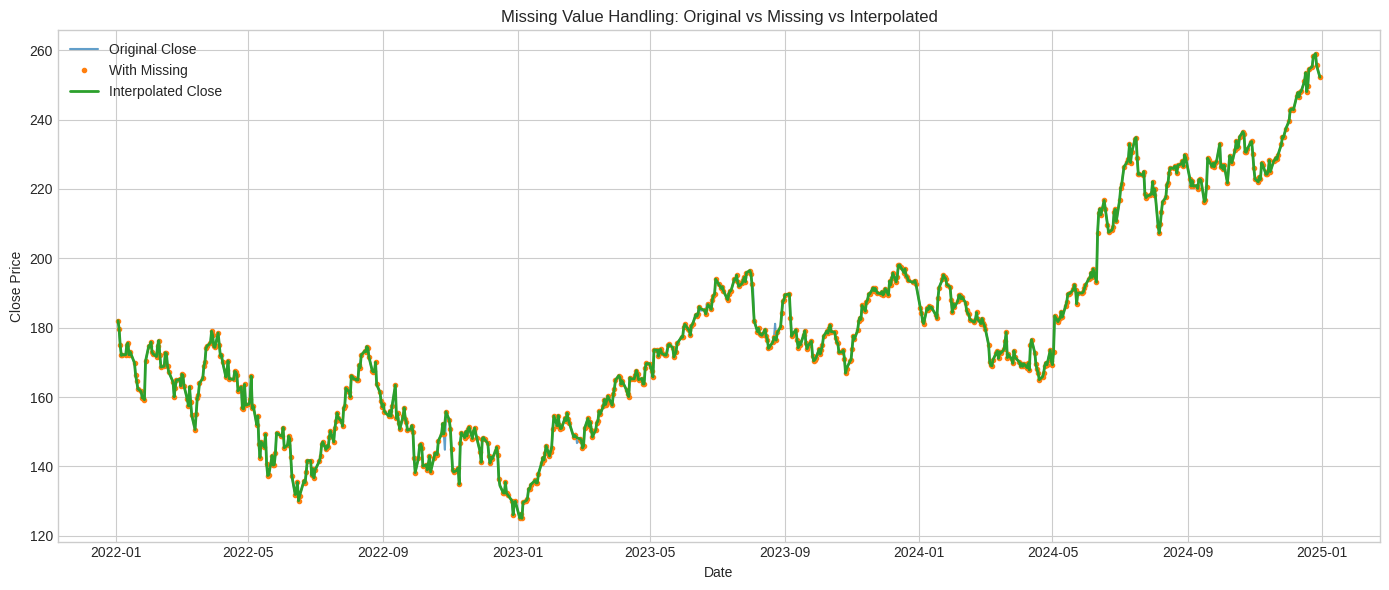

In [ ]:
# ============================================
# 9. 결측치 처리 결과 시각화
# ============================================

plt.figure(figsize=(14, 6))
plt.plot(df.index, df["Close"], label="Original Close", alpha=0.7)
plt.plot(df_missing.index, df_missing["Close"], label="With Missing", linestyle="None", marker="o", markersize=3)
plt.plot(df_interp.index, df_interp["Close"], label="Interpolated Close", linewidth=2)

plt.title("Missing Value Handling: Original vs Missing vs Interpolated")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.tight_layout()
plt.show()


## 8. 로그 수익률 계산
금융 데이터에서는 가격 자체보다 **수익률**을 보는 경우가 많습니다.  
특히 로그 수익률은 이후 정상성, 변동성, 이상치 분석에서 자주 사용됩니다.


In [ ]:
# ============================================
# 10. 로그 수익률 계산
# ============================================

df["Log_Return"] = np.log(df["Close"] / df["Close"].shift(1))

display(df[["Close", "Log_Return"]].head(10))


Price,Close,Log_Return
Ticker,AAPL,
Date,,
2022-01-03,182.009995,NaN
2022-01-04,179.699997,-0.012773
2022-01-05,174.919998,-0.026960
2022-01-06,172.000000,-0.016834
2022-01-07,172.169998,0.000988
2022-01-10,172.190002,0.000116
2022-01-11,175.080002,0.016644
2022-01-12,175.529999,0.002567


## 9. 이상치 후보 탐색
이상치(Outlier)는 무조건 제거해야 하는 값이 아닙니다.  
실제 충격일 수도 있고, 단순 오류일 수도 있습니다.

여기서는 **로그 수익률의 표준점수(z-score)** 를 사용하여 이상치 후보를 탐색합니다.  
일반적으로 절댓값이 큰 관측치일수록 극단값 후보로 볼 수 있습니다.


In [ ]:
# ============================================
# 11. 이상치 후보 탐색
# ============================================

returns = df["Log_Return"].dropna().copy()
z_score = (returns - returns.mean()) / returns.std()

outlier_candidates = pd.DataFrame({
    "Log_Return": returns,
    "Z_Score": z_score
})

outlier_candidates = outlier_candidates.loc[np.abs(outlier_candidates["Z_Score"]) > 3]

print("절댓값 3 초과 z-score 관측치 개수:", len(outlier_candidates))
display(outlier_candidates.head(10))


절댓값 3 초과 z-score 관측치 개수: 9


,Log_Return,Z_Score
Date,,
2022-01-28,0.067451,3.931479
2022-05-05,-0.057328,-3.388615
2022-05-11,-0.053233,-3.148376
2022-05-18,-0.058073,-3.432305
2022-09-13,-0.060472,-3.573005
2022-10-28,0.072834,4.247307
2022-11-10,0.085236,4.974862
2024-05-03,0.058096,3.382657
2024-06-11,0.070131,4.088733


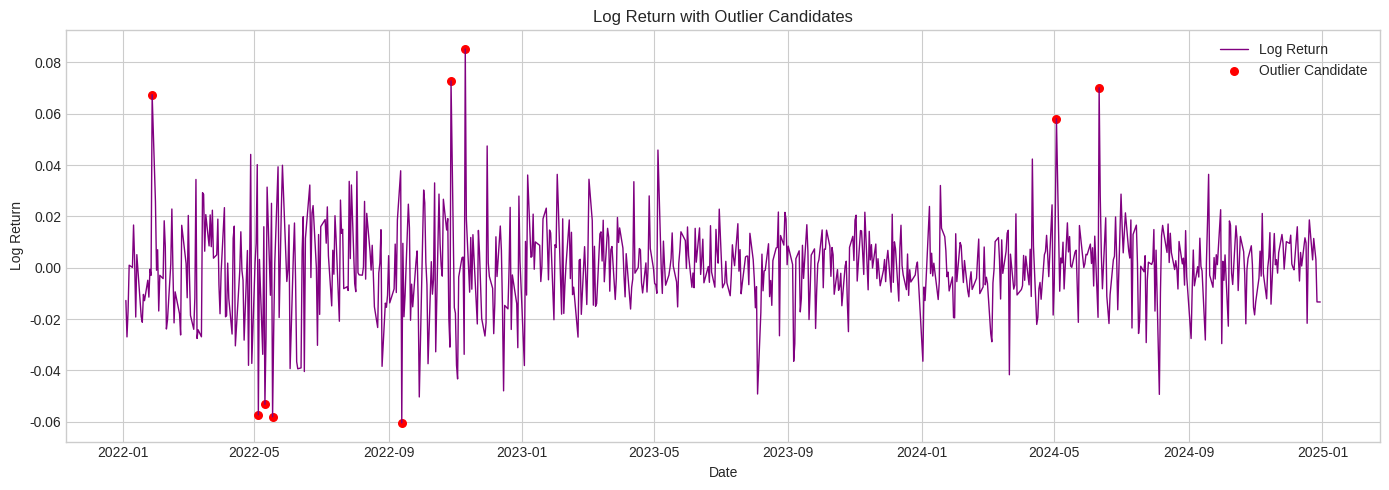

In [ ]:
# ============================================
# 12. 로그 수익률과 이상치 후보 시각화
# ============================================

plt.figure(figsize=(14, 5))
plt.plot(df.index, df["Log_Return"], label="Log Return", color="purple", linewidth=1)

if len(outlier_candidates) > 0:
    plt.scatter(
        outlier_candidates.index,
        outlier_candidates["Log_Return"],
        color="red",
        s=30,
        label="Outlier Candidate"
    )

plt.title("Log Return with Outlier Candidates")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.legend()
plt.tight_layout()
plt.show()


## 10. Rolling Statistics 계산
롤링 평균과 롤링 표준편차는 데이터의 흐름과 변동성 변화를 이해하는 가장 기본적인 도구입니다.

- **Rolling Mean**: 최근 구간의 평균
- **Rolling Std**: 최근 구간의 표준편차

이는 이후 정상성 판단이나 변동성 해석의 기초가 됩니다.


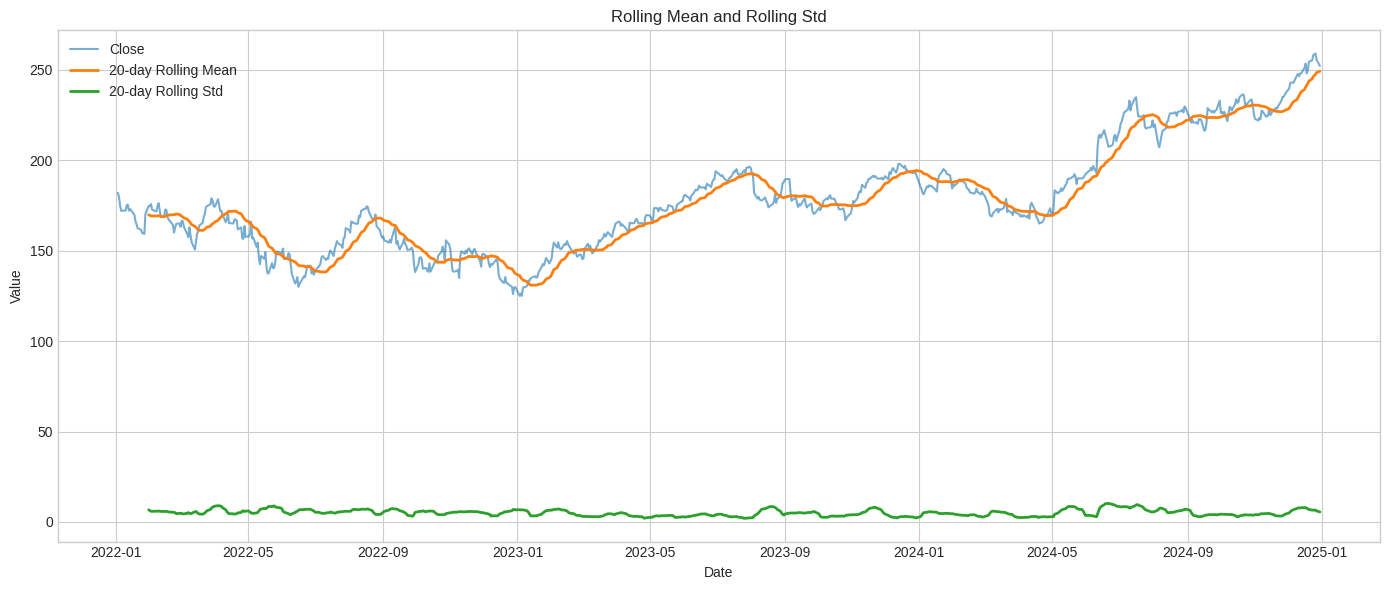

In [ ]:
# ============================================
# 13. 롤링 평균과 롤링 표준편차
# ============================================

df["RollMean20"] = df["Close"].rolling(window=20).mean()
df["RollStd20"] = df["Close"].rolling(window=20).std()

plt.figure(figsize=(14, 6))
plt.plot(df.index, df["Close"], label="Close", alpha=0.6)
plt.plot(df.index, df["RollMean20"], label="20-day Rolling Mean", linewidth=2)
plt.plot(df.index, df["RollStd20"], label="20-day Rolling Std", linewidth=2)

plt.title("Rolling Mean and Rolling Std")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()


## 11. 재표집(Resampling): 일별 데이터를 주별·월별로 바꾸기
시계열 분석에서는 데이터의 빈도를 바꾸는 일이 매우 흔합니다.

예를 들어:
- 일별 → 주별
- 일별 → 월별
- 시간별 → 일별

여기서는 `Close`를 기준으로 주별 마지막 값과 월별 마지막 값을 계산합니다.


In [ ]:
# ============================================
# 14. 주별/월별 재표집
# ============================================

weekly_close = df[('Close', ticker)].resample("W").last()
monthly_close = df[('Close', ticker)].resample("M").last()

print("주별 데이터 개수:", len(weekly_close))
print("월별 데이터 개수:", len(monthly_close))

display(pd.DataFrame({
    "Weekly_Close": weekly_close.head(),
    "Monthly_Close": monthly_close.head()
}))

주별 데이터 개수: 157
월별 데이터 개수: 36


,Weekly_Close,Monthly_Close
Date,,
2022-01-09,172.169998,NaN
2022-01-16,173.070007,NaN
2022-01-23,162.410004,NaN
2022-01-30,170.330002,NaN
2022-01-31,NaN,174.779999
2022-02-06,172.389999,NaN
2022-02-28,NaN,165.119995
2022-03-31,NaN,174.610001
2022-04-30,NaN,157.649994


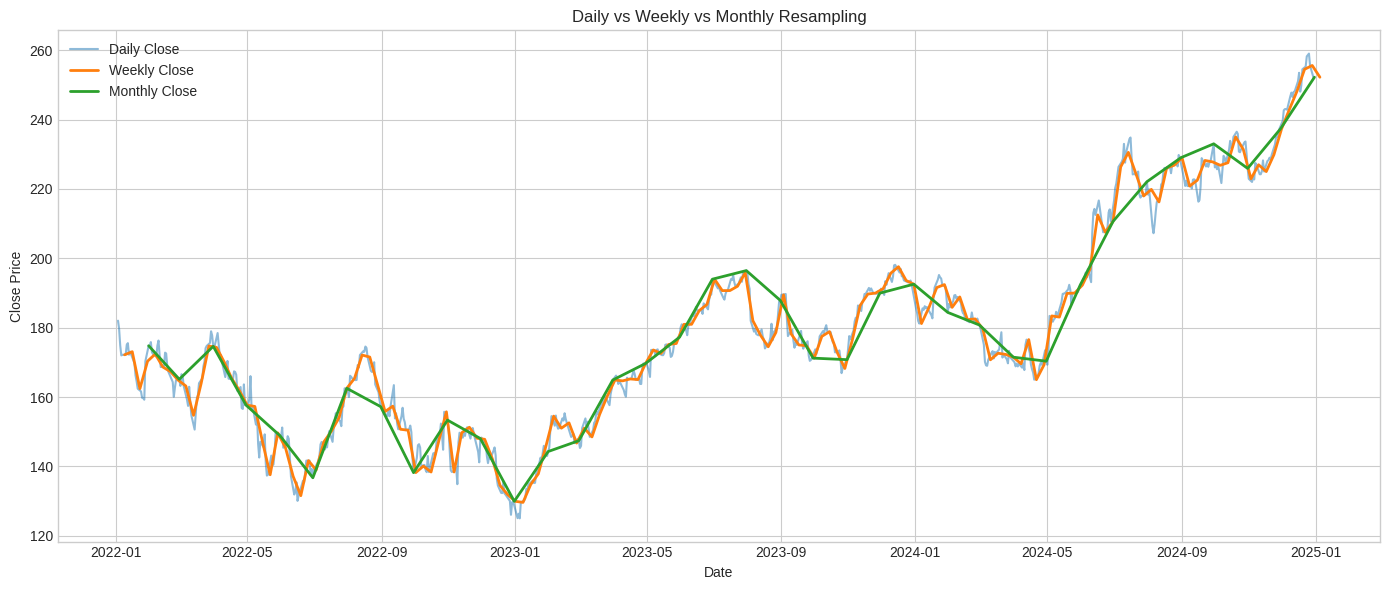

In [ ]:
# ============================================
# 15. 재표집 결과 시각화
# ============================================

plt.figure(figsize=(14, 6))
plt.plot(df.index, df["Close"], label="Daily Close", alpha=0.5)
plt.plot(weekly_close.index, weekly_close, label="Weekly Close", linewidth=2)
plt.plot(monthly_close.index, monthly_close, label="Monthly Close", linewidth=2)

plt.title("Daily vs Weekly vs Monthly Resampling")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.tight_layout()
plt.show()


## 12. 실습 정리
이번 실습에서 확인한 핵심은 다음과 같습니다.

- 시간 인덱스는 시계열 분석의 출발점이다.
- 거래 데이터는 완전한 일별 빈도를 가지지 않을 수 있다.
- 결측치는 삭제와 보간의 결과가 다르며, 시계열에서는 시간축 연속성이 중요하다.
- 이상치는 오류일 수도 있고 실제 충격일 수도 있다.
- 롤링 통계는 흐름과 변동성 변화를 읽는 데 유용하다.
- 재표집은 분석 목적에 맞는 시간 단위를 만드는 핵심 도구이다.


## 13. 연습문제 (Exercises)

1. 애플 대신 마이크로소프트(MSFT) 데이터를 다운로드하여 같은 전처리 과정을 반복해 보시오.

2. `dropna()`와 `interpolate()`를 각각 적용했을 때, 데이터 길이가 어떻게 달라지는지 설명하시오.

3. `window=5`, `window=60` 롤링 평균을 각각 계산한 뒤 두 결과의 차이를 시각적으로 비교하시오.

4. 로그 수익률의 절댓값이 가장 큰 날짜 5개를 찾아, 실제 어떤 사건이 있었는지 조사해 보시오.

5. `resample("Q")`를 사용하여 분기별 종가를 생성하고 그래프로 비교하시오.
